In [32]:
## Import statements

import numpy as np
import networkx as nx
import polars as pl
import matplotlib.pyplot as plt
import json
from typing import List, Tuple
import polars as pl
import networkx as nx
import pandas as pd


## Helper functions

In [18]:
## Helper functions 

# ---------------------------
# Plot helpers (adapted from snippet)
# ---------------------------

def plot_assort_hist(r_emp, r_list, savepath=None):
    plt.figure()
    plt.hist(r_list, bins=30)
    plt.axvline(r_emp, color='red', linestyle='--', linewidth=2, label='Empirical assortativity')
    plt.xlabel('Degree assortativity, r')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300)
    plt.show()


def plot_betweenness_diff(nodes, meandiff, q25, q75, nodedict=None, savepath=None):
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(nodes)), meandiff, marker='o')
    plt.plot([0, len(nodes) - 1], [0, 0], 'k--')
    plt.fill_between(range(len(nodes)), q25, q75, alpha=0.5)
    if nodedict is not None:
        plt.xticks(list(nodedict.keys()), list(nodedict.values()), rotation=90)
    else:
        plt.xticks(range(len(nodes)), nodes, rotation=90)
    plt.xlabel('Vertex Label')
    plt.ylabel('Difference in Betweenness Centrality')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300)
    plt.show()



## Question 1, Part B

-- function configuration_model()
takes array of degrees, returns edge list. 
Check degree sum is even, expand degree list into nodes. num times node is in list = degree. 
create edge list with random permutations (`numpy.random.shuffle`)
`return_graph` param to return edge list or as NetworkX MultiGraph obj


In [6]:
#---------------------------
# Configuration model function
# ---------------------------


def configuration_model(degrees: List[int], return_graph: bool = False):
    """
    Simple implementation of the configuration model using stub pairing.


    Parameters
    ----------
    degrees : list of int
    Degree for each node (length = N)
    return_graph : bool
    If True, return a NetworkX MultiGraph; otherwise return edge list (list of tuples)
        """
    if sum(degrees) % 2 != 0:
        raise ValueError("Sum of degrees must be even.")


    # build stub list
    nodes = []
    for i, d in enumerate(degrees):
        nodes.extend([i] * int(d))

    nodes = np.array(nodes)
    np.random.shuffle(nodes)

    edges = [(int(nodes[i]), int(nodes[i + 1])) for i in range(0, len(nodes), 2)]


    if return_graph:
        G = nx.MultiGraph()
        G.add_edges_from(edges)
        return G
    else:
        return edges

### Testing configuration model function 

In [7]:
degrees = [2, 3, 1, 2, 2]  # small test
edges = configuration_model(degrees)
print(edges[:10])


[(2, 4), (3, 4), (1, 3), (1, 0), (1, 0)]


In [ ]:
G = configuration_model(degrees, return_graph=True)
nx.draw(G)          


## Question 1C

Create degree dist with truncated power-law distribution. Parameters in pdf. 

In [9]:
import numpy as np

## from Prof. Landry
def power_law(n: int, 
            minval: int, maxval: int,
            alpha: float, seed: int | None = None
    ) -> np.ndarray:
    """
    Generates a power law distribution of random integers.

    Parameters
    ----------
    n : int
        The number of random integers to generate.
    minval : int
        The minimum value of the random integers.
    maxval : int
        The maximum value of the random integers.
    alpha : float
        The exponent of the power law distribution.
    seed : int, optional
        The seed value for the random number generator.

    Returns
    -------
    numpy.ndarray
        An array of random integers following a power law distribution.
    """
    if seed is not None:
        np.random.seed(seed)
    u = np.random.random(n)

    if alpha == -1:
        # Special case for alpha = -1 to avoid division by zero
        return np.round(
            np.exp(
                np.log(minval - 0.5) + u * (np.log(maxval + 0.5) - np.log(minval - 0.5))
            )
        ).astype(int)
    else:
        # General case
        a = (minval - 0.5) ** (1 + alpha)
        b = (maxval + 0.5) ** (1 + alpha)
        return np.round((a + u * (b - a)) ** (1 / (1 + alpha))).astype(int)

In [4]:
# ---------------------------
# Question 1c: Truncated power-law experiments
# ---------------------------


def experiment_truncated_powerlaw(N=1000, alpha=-2.5, n_iter=1000, seed=None):
    """
    Generate degree sequences from truncated power law and compute fraction of self-loops
    and multi-edges averaged over n_iter realizations.
    Returns (mean_self_loop_fraction, mean_multi_edge_fraction)
            """
    self_fracs = []
    multi_fracs = []
    rng = np.random.default_rng(seed)


    for it in range(n_iter):
        degs = power_law(N, minval=1, maxval=N - 1, alpha=alpha)
        # ensure even sum
        if degs.sum() % 2 != 0:
            idx = rng.integers(0, N)
            degs[idx] += 1


    G = configuration_model(list(degs), return_graph=True)
    m = G.number_of_edges()
    # count self loops
    num_self_loops = len(list(nx.selfloop_edges(G)))
    # count multi-edges: for each pair, count multiplicity >1
    # Note: G.edges() in MultiGraph yields each edge instance; we need to evaluate multiplicity
    multiplicities = 0
    seen = set()


    for u, v in G.edges():
        key = (min(u, v), max(u, v))
        if key in seen:
            multiplicities += 1
        else:
            seen.add(key)

            
    # multiplicities counts additional edges beyond the first for each unordered pair
    self_fracs.append(num_self_loops / m)
    multi_fracs.append(multiplicities / m)


    return np.mean(self_fracs), np.mean(multi_fracs)

In [10]:
mean_self, mean_multi = experiment_truncated_powerlaw(N=1000, alpha=-2.5, n_iter=1000)
print("Average self-loop fraction:", mean_self)
print("Average multi-edge fraction:", mean_multi)


Average self-loop fraction: 0.006550218340611353
Average multi-edge fraction: 0.024017467248908297


### Problem 1D - Compare to Budapest Connectome 

In [13]:
def load_budapest_connectome(path: str):
    """
    Loads the Budapest connectome dataset (semicolon-separated file)
    and returns a weighted MultiGraph.
    Expected columns:
        'id node1', 'id node2', 'edge weight(med nof)'
    """
    # Use semicolon separator
    df = pl.read_csv(path, separator=';')

    # Extract relevant columns
    if 'id node1' not in df.columns or 'id node2' not in df.columns:
        raise ValueError("Columns 'id node1' and 'id node2' not found in CSV.")

    # Edge weight optional
    has_weight = 'edge weight(med nof)' in df.columns

    # Build edge list
    if has_weight:
        edgelist = [(int(row[0]), int(row[1]), float(row[2])) 
                    for row in df.select(['id node1', 'id node2', 'edge weight(med nof)']).rows()]
    else:
        edgelist = [(int(row[0]), int(row[1])) 
                    for row in df.select(['id node1', 'id node2']).rows()]

    # Create MultiGraph
    if has_weight:
        G = nx.MultiGraph()
        for u, v, w in edgelist:
            G.add_edge(u, v, weight=w)
    else:
        G = nx.MultiGraph()
        G.add_edges_from(edgelist)

    print(f"Loaded Budapest connectome with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

    


In [14]:
def budapest_assortativity_vs_config(G_empirical: nx.Graph, n_iter=1000, seed=None):
    """
    Generates n_iter configuration-model graphs preserving empirical degree sequence and
    computes degree assortativity for each.
    Returns (r_empirical, r_random_list)
    """
    degrees = [d for n, d in G_empirical.degree()]  # use unweighted degree
    r_emp = nx.degree_assortativity_coefficient(G_empirical)
    r_list = []
    rng = np.random.default_rng(seed)

    for _ in range(n_iter):
        G_rand = configuration_model(degrees, return_graph=True)
        r_list.append(nx.degree_assortativity_coefficient(G_rand))

    return r_emp, r_list


In [12]:
## Read budapest data in 
df = pl.read_csv("connectome.csv", separator=";") 

# create edge list and graph 
edgelist_budapest = df[["id node1", "id node2"]].rows()
G = nx.MultiGraph(edgelist_budapest)

Loaded Budapest connectome with 480 nodes and 1000 edges.


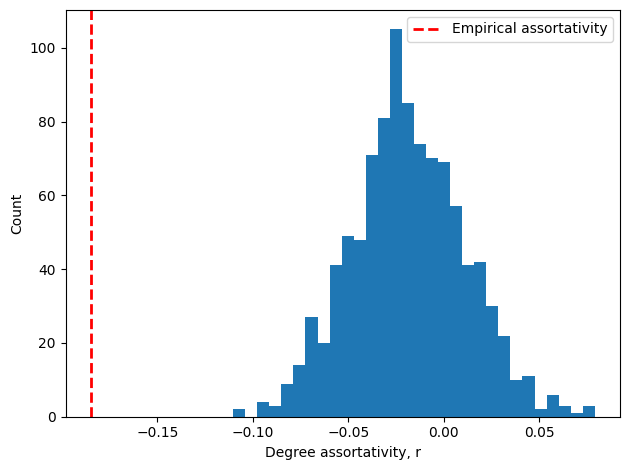

In [19]:
G_bud = load_budapest_connectome("connectome.csv")
r_emp, r_list = budapest_assortativity_vs_config(G_bud, n_iter=1000, seed=42)
plot_assort_hist(r_emp, r_list)


## Problem 2a: Medici Centralities

In [34]:
def medici_centralities():
    G = nx.florentine_families_graph()
    centralities = {
        'degree': nx.degree_centrality(G),
        'harmonic': nx.harmonic_centrality(G),
        'eigenvector': nx.eigenvector_centrality(G, max_iter=1000),
        'betweenness': nx.betweenness_centrality(G)
    }

    # create sorted tables (list of (node, score) sorted descending)
    sorted_tables = {}
    for k, d in centralities.items():
        sorted_tables[k] = sorted(d.items(), key=lambda x: x[1], reverse=True)

    return G, sorted_tables


In [40]:
G, sorted_tables = medici_centralities()

for centrality_name, table in sorted_tables.items():
    print(f"\n=== {centrality_name.capitalize()} Centrality ===")
    for family, score in table:
        print(f"{family:15s}  {score:.4f}")



=== Degree Centrality ===
Medici           0.4286
Strozzi          0.2857
Guadagni         0.2857
Castellani       0.2143
Peruzzi          0.2143
Ridolfi          0.2143
Tornabuoni       0.2143
Albizzi          0.2143
Bischeri         0.2143
Barbadori        0.1429
Salviati         0.1429
Acciaiuoli       0.0714
Pazzi            0.0714
Ginori           0.0714
Lamberteschi     0.0714

=== Harmonic Centrality ===
Medici           9.5000
Guadagni         8.0833
Ridolfi          8.0000
Tornabuoni       7.8333
Strozzi          7.8333
Albizzi          7.8333
Bischeri         7.2000
Barbadori        7.0833
Castellani       6.9167
Peruzzi          6.7833
Salviati         6.5833
Acciaiuoli       5.9167
Lamberteschi     5.3667
Ginori           5.3333
Pazzi            4.7667

=== Eigenvector Centrality ===
Medici           0.4303
Strozzi          0.3560
Ridolfi          0.3416
Tornabuoni       0.3258
Guadagni         0.2891
Bischeri         0.2828
Peruzzi          0.2757
Castellani       0.2590


In [41]:
import networkx as nx

## write the latex for me 


for centrality_name, table in sorted_tables.items():
    print(f"\\subsection*{{{centrality_name.capitalize()} Centrality}}")
    print("\\begin{tabular}{l r}")
    print("\\hline")
    print("Family & Score \\\\")
    print("\\hline")
    for family, score in table:
        print(f"{family} & {score:.4f} \\\\")
    print("\\hline")
    print("\\end{tabular}\n")


\subsection*{Degree Centrality}
\begin{tabular}{l r}
\hline
Family & Score \\
\hline
Medici & 0.4286 \\
Strozzi & 0.2857 \\
Guadagni & 0.2857 \\
Castellani & 0.2143 \\
Peruzzi & 0.2143 \\
Ridolfi & 0.2143 \\
Tornabuoni & 0.2143 \\
Albizzi & 0.2143 \\
Bischeri & 0.2143 \\
Barbadori & 0.1429 \\
Salviati & 0.1429 \\
Acciaiuoli & 0.0714 \\
Pazzi & 0.0714 \\
Ginori & 0.0714 \\
Lamberteschi & 0.0714 \\
\hline
\end{tabular}

\subsection*{Harmonic Centrality}
\begin{tabular}{l r}
\hline
Family & Score \\
\hline
Medici & 9.5000 \\
Guadagni & 8.0833 \\
Ridolfi & 8.0000 \\
Tornabuoni & 7.8333 \\
Strozzi & 7.8333 \\
Albizzi & 7.8333 \\
Bischeri & 7.2000 \\
Barbadori & 7.0833 \\
Castellani & 6.9167 \\
Peruzzi & 6.7833 \\
Salviati & 6.5833 \\
Acciaiuoli & 5.9167 \\
Lamberteschi & 5.3667 \\
Ginori & 5.3333 \\
Pazzi & 4.7667 \\
\hline
\end{tabular}

\subsection*{Eigenvector Centrality}
\begin{tabular}{l r}
\hline
Family & Score \\
\hline
Medici & 0.4303 \\
Strozzi & 0.3560 \\
Ridolfi & 0.3416 \\
Torna

## Problem 2b: Further analysis of centarlity measures

In [27]:
def betweenness_vs_config(G: nx.Graph, n_iter=1000, seed=None):
    """
    Compare empirical betweenness to a configuration-model ensemble.
    Works for labeled graphs (e.g. Florentine families).
    Returns node list, mean difference, 25% quantile, 75% quantile.
    """
    rng = np.random.default_rng(seed)

    # Empirical betweenness
    b_emp = nx.betweenness_centrality(G)
    nodes = list(G.nodes())
    N = len(nodes)

    # Degree sequence
    degrees = [deg for _, deg in G.degree()]

    # Initialize storage
    b_random = {node: [] for node in nodes}

    for _ in range(n_iter):
        # Generate random config-model graph
        G_rand = configuration_model(degrees, return_graph=True)

        # Compute betweenness for random graph (labeled 0..N-1)
        b_rand = nx.betweenness_centrality(G_rand)

        # Map numeric nodes (0..N-1) to original labels
        for i, node in enumerate(nodes):
            b_random[node].append(b_rand.get(i, 0))

    # Compute mean and quantiles for each node
    meandiff, q25, q75 = [], [], []
    for node in nodes:
        arr = np.array(b_random[node])
        mean_val = np.mean(arr)
        meandiff.append(b_emp[node] - mean_val)
        q25.append(np.quantile(arr, 0.25))
        q75.append(np.quantile(arr, 0.75))

    return nodes, np.array(meandiff), np.array(q25), np.array(q75)


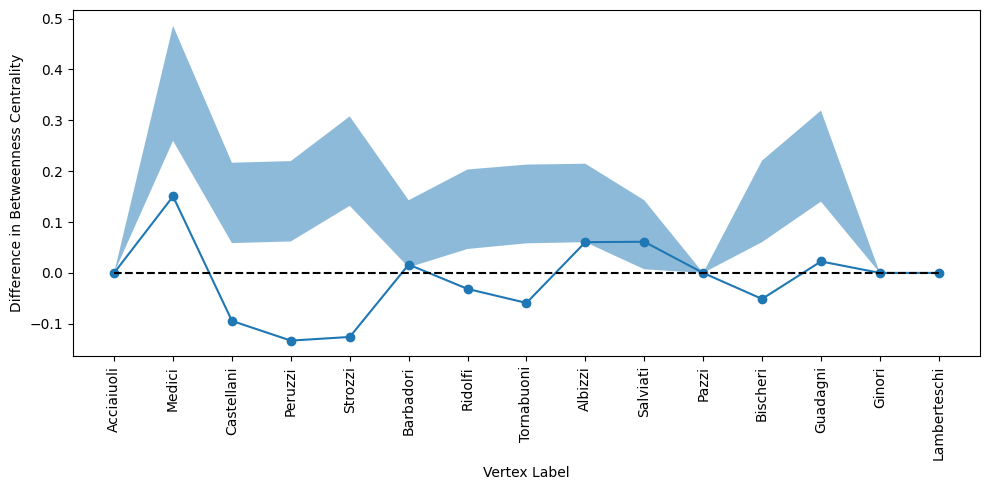

In [29]:
G_med = nx.florentine_families_graph()
nodes, meandiff, q25, q75 = betweenness_vs_config(G_med, n_iter=1000, seed=42)
plot_betweenness_diff(list(range(len(nodes))), meandiff, q25, q75, nodedict={i: n for i, n in enumerate(nodes)})
